# DDPM Tasks 6-7

This notebook is the heavier experiment pass: a stronger Task 7 run, a schedule ablation with more training, a timestep-count ablation, and a few visual sanity checks.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.datasets import make_moons

from src.train import load_ddpm_checkpoint, train_ddpm
from src.eval import (
    run_task7_diagnostics,
    run_task7_full_evaluation,
    run_task6_ablation,
    run_task6_timestep_ablation,
    sliced_wasserstein_distance_2d,
    rbf_mmd_2d,
    save_toy_scatter,
)

sns.set_theme(style="whitegrid")


In [11]:
TASK7_CKPT = Path("outputs/checkpoints/tiny_unet_mnist_task7_eval_deep.pt")
RUN_TASK7_TRAIN = True  # set False to reuse existing Task 7 checkpoint

TASK7_TRAIN_STEPS = 7000
TASK7_BATCH_SIZE = 128
TASK7_SAMPLE_EVERY = 2000
TASK7_UNET_VARIANT = "deep"
TASK7_UNET_TIME_DIM = 256
TASK7_UNET_BASE_CHANNELS = 64

TASK7_EVAL_NUM_SAMPLES = 1024
TASK7_EVAL_REAL_SAMPLES = 2048
TASK7_EVAL_NN_POOL = 10000
TASK7_CLASSIFIER_EPOCHS = 2
TASK7_ELBO_NUM_BATCHES = 3
TASK7_ELBO_TIMESTEP_STRIDE = 50

SCHEDULE_ABLATION_STEPS = 3000
SCHEDULE_ABLATION_TIMESTEPS = 1000
SCHEDULE_ABLATION_NUM_SAMPLES = 256
SCHEDULE_ABLATION_REAL_SAMPLES = 2048
SCHEDULE_ABLATION_NN_POOL = 10000
SCHEDULE_ABLATION_CLASSIFIER_EPOCHS = 2
SCHEDULE_ABLATION_ELBO_NUM_BATCHES = 3
SCHEDULE_ABLATION_ELBO_TIMESTEP_STRIDE = 50

TIMESTEP_ABLATION_VALUES = (1000, 750, 500, 250)
TIMESTEP_ABLATION_SEEDS = (2026, 2027, 2028)
TIMESTEP_ABLATION_STEPS = 1500
TIMESTEP_ABLATION_NUM_SAMPLES = 256
TIMESTEP_ABLATION_REAL_SAMPLES = 2048
TIMESTEP_ABLATION_NN_POOL = 10000
TIMESTEP_ABLATION_CLASSIFIER_EPOCHS = 2
TIMESTEP_ABLATION_ELBO_NUM_BATCHES = 3
TIMESTEP_ABLATION_ELBO_TIMESTEP_STRIDE = 50

if RUN_TASK7_TRAIN or (not TASK7_CKPT.exists()):
    model_d, schedule_d, losses_d, task7_train_stats = train_ddpm(
        steps=TASK7_TRAIN_STEPS,
        batch_size=TASK7_BATCH_SIZE,
        sample_every=TASK7_SAMPLE_EVERY,
        unet_variant=TASK7_UNET_VARIANT,
        unet_time_dim=TASK7_UNET_TIME_DIM,
        unet_base_channels=TASK7_UNET_BASE_CHANNELS,
        checkpoint_path=TASK7_CKPT,
        return_stats=True,
    )
    print("Task 7 training done. Last loss:", losses_d[-1])
    print("Saved checkpoint:", TASK7_CKPT)
    print("Periodic sample grids:")
    for p in task7_train_stats["sample_paths"]:
        print(" -", p)
else:
    model_d, schedule_d = load_ddpm_checkpoint(TASK7_CKPT)
    losses_d = []
    task7_train_stats = {"sample_paths": []}
    print("Loaded Task 7 checkpoint:", TASK7_CKPT)


In [ ]:

if RUN_TASK7_TRAIN or (not TASK7_CKPT.exists()):
    model_d, schedule_d, losses_d, task7_train_stats = train_ddpm(
        steps=TASK7_TRAIN_STEPS,
        batch_size=TASK7_BATCH_SIZE,
        sample_every=TASK7_SAMPLE_EVERY,
        unet_variant=TASK7_UNET_VARIANT,
        unet_time_dim=TASK7_UNET_TIME_DIM,
        unet_base_channels=TASK7_UNET_BASE_CHANNELS,
        checkpoint_path=TASK7_CKPT,
        return_stats=True,
    )
    print("Task 7 training done. Last loss:", losses_d[-1])
    print("Saved checkpoint:", TASK7_CKPT)
    print("Periodic sample grids:")
    for p in task7_train_stats["sample_paths"]:
        print(" -", p)
else:
    model_d, schedule_d = load_ddpm_checkpoint(TASK7_CKPT)
    losses_d = []
    task7_train_stats = {"sample_paths": []}
    print("Loaded Task 7 checkpoint:", TASK7_CKPT)


Task 4 Training:   0%|          | 0/7000 [00:00<?, ?it/s]

Task 7 training done. Last loss: 0.02414594776928425
Saved checkpoint: outputs\checkpoints\tiny_unet_mnist_task7_eval_deep.pt
Periodic sample grids:
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\train_step_002000.png
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\train_step_004000.png
 - C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\samples\train_step_006000.png


## Task 7:


In [3]:
if len(losses_d) == 0:
    print("No in-memory training losses (checkpoint loaded). Using placeholder for loss curve artifact.")
    losses_for_diag = [0.0]
else:
    losses_for_diag = losses_d

diagnostic_paths = run_task7_diagnostics(model_d, schedule_d, losses_for_diag)
diagnostic_paths


{'loss_curve': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task7_loss_curve.png',
 'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_samples.png',
 'trajectory': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_trajectory.png'}

In [4]:
task7_results = run_task7_full_evaluation(
    model=model_d,
    schedule=schedule_d,
    losses=losses_for_diag,
    num_samples=TASK7_EVAL_NUM_SAMPLES,
    metrics_real_samples=TASK7_EVAL_REAL_SAMPLES,
    nn_train_samples=TASK7_EVAL_NN_POOL,
    classifier_epochs=TASK7_CLASSIFIER_EPOCHS,
    elbo_num_batches=TASK7_ELBO_NUM_BATCHES,
    elbo_timestep_stride=TASK7_ELBO_TIMESTEP_STRIDE,
)
task7_results


c:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\src\eval.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_pat

{'loss_curve': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task7_loss_curve.png',
 'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_samples.png',
 'trajectory': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task7_trajectory.png',
 'nearest_neighbor_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task7_nearest_neighbors.png',
 'classifier_test_accuracy': 0.9736328125,
 'classifier_feature_extractor_checkpoint': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\checkpoints\\mnist_eval_classifier.pt',
 'classifier_feature_extractor_retrained_now': 0.0,
 'feature_fid_test': 31.574038766792896,
 'feature_fid_train': 36.66923185046404,
 'feature_kid_test': 9.189155733069873,
 'feature_kid_train': 16.39699075836508,
 'feature

In [5]:
task7_df = pd.DataFrame([task7_results])
display(task7_df.T.rename(columns={0: "value"}))

task7_plot_cols = [
    c for c in [
        "feature_fid_test",
        "feature_kid_test",
        "generated_class_entropy_normalized",
        "generated_mean_confidence",
        "bpd_mean",
    ]
    if c in task7_df.columns
]

,value
loss_curve,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
sample_grid,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
trajectory,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
nearest_neighbor_grid,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
classifier_test_accuracy,0.973633
classifier_feature_extractor_checkpoint,C:\Users\ahmad\Documents\GitHub\Learning Diffu...
classifier_feature_extractor_retrained_now,0.0
feature_fid_test,31.574039
feature_fid_train,36.669232
feature_kid_test,9.189156


## Task 6: Schedule ablation

This pass uses a stronger compute budget than the quick diagnostic run so the linear-vs-cosine comparison is less dominated by noise.

In [6]:
ablation_results = run_task6_ablation(
    train_steps=SCHEDULE_ABLATION_STEPS,
    timesteps=SCHEDULE_ABLATION_TIMESTEPS,
    num_samples=SCHEDULE_ABLATION_NUM_SAMPLES,
    metrics_real_samples=SCHEDULE_ABLATION_REAL_SAMPLES,
    nn_train_samples=SCHEDULE_ABLATION_NN_POOL,
    classifier_epochs=SCHEDULE_ABLATION_CLASSIFIER_EPOCHS,
    elbo_num_batches=SCHEDULE_ABLATION_ELBO_NUM_BATCHES,
    elbo_timestep_stride=SCHEDULE_ABLATION_ELBO_TIMESTEP_STRIDE,
)
ablation_results


c:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\src\eval.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_pat

Task 4 Training:   0%|          | 0/3000 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/3000 [00:00<?, ?it/s]

[{'name': 'linear',
  'schedule_type': 'linear',
  'unet_variant': 'deep',
  'unet_time_dim': 256.0,
  'unet_base_channels': 64.0,
  'beta_end': 0.02,
  'final_loss': 0.026513444259762764,
  'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task6_linear_samples.png',
  'nearest_neighbor_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task6_linear_nearest_neighbors.png',
  'classifier_test_accuracy': 0.9736328125,
  'classifier_feature_extractor_checkpoint': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\checkpoints\\mnist_eval_classifier.pt',
  'classifier_feature_extractor_retrained_now': 0.0,
  'feature_fid_test': 90.87602249960503,
  'feature_fid_train': 98.81969177795965,
  'feature_kid_test': 38.02037311099311,
  'feature_kid_train': 50.24810255658093,
  'feature_fid_train_minus_test': 7.943669278354619,
  'feature_kid_tr

,name,schedule_type,final_loss,feature_fid_test,feature_kid_test,generated_class_entropy_normalized,generated_mean_confidence,bpd_mean
1,cosine,cosine,0.039037,71.862405,25.776766,0.982899,0.868164,6.890532
0,linear,linear,0.026513,90.876022,38.020373,0.962247,0.871880,9.651670


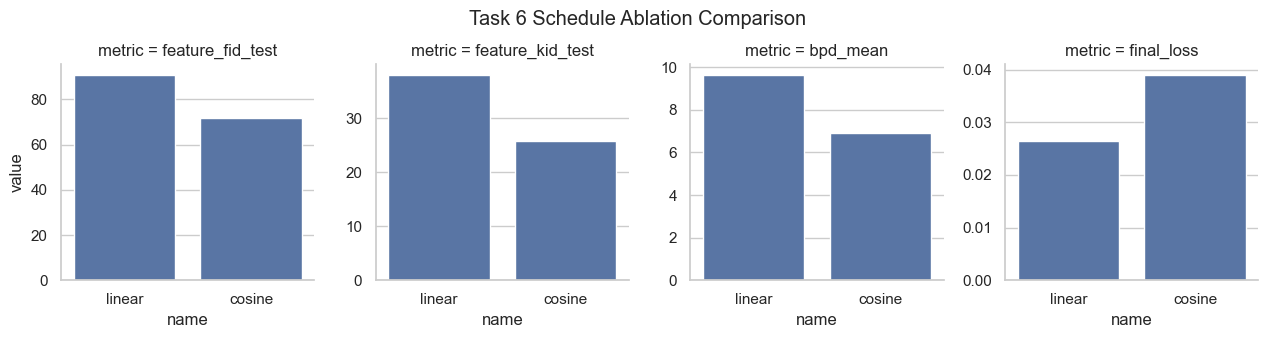

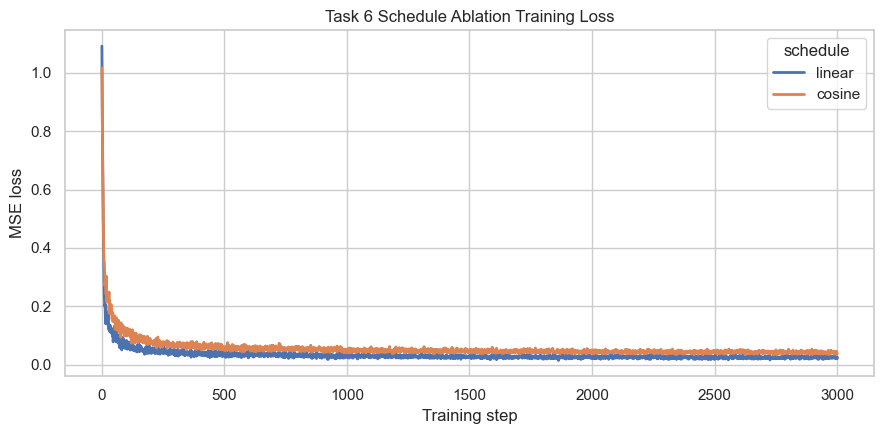

In [7]:
ablation_df = pd.DataFrame(ablation_results)
schedule_table_cols = [
    c for c in [
        "name",
        "schedule_type",
        "final_loss",
        "feature_fid_test",
        "feature_kid_test",
        "generated_class_entropy_normalized",
        "generated_mean_confidence",
        "bpd_mean",
    ]
    if c in ablation_df.columns
]
display(ablation_df[schedule_table_cols].sort_values("feature_fid_test"))

schedule_plot_cols = [c for c in ["feature_fid_test", "feature_kid_test", "bpd_mean", "final_loss"] if c in ablation_df.columns]
if len(schedule_plot_cols) > 0:
    plot_df = ablation_df.melt(id_vars=["name"], value_vars=schedule_plot_cols, var_name="metric", value_name="value")
    g = sns.catplot(data=plot_df, kind="bar", x="name", y="value", col="metric", sharey=False, height=3.2, aspect=1.0)
    g.fig.suptitle("Task 6 Schedule Ablation Comparison", y=1.05)
    plt.show()

loss_rows = []
for _, row in ablation_df.iterrows():
    for step, loss in enumerate(row["loss_history"], start=1):
        loss_rows.append({"schedule": row["name"], "step": step, "loss": loss})

loss_df = pd.DataFrame(loss_rows)
plt.figure(figsize=(9, 4.5))
sns.lineplot(data=loss_df, x="step", y="loss", hue="schedule", linewidth=2.0)
plt.title("Task 6 Schedule Ablation Training Loss")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.tight_layout()
plt.show()


## Task 6: Timestep-count ablation

This version is more robust than the quick pass: it tests more timestep values, repeats each run across fixed seeds, and summarizes the comparison with mean/std instead of trusting a single run.

In [12]:
timestep_ablation_results = run_task6_timestep_ablation(
    timestep_values=TIMESTEP_ABLATION_VALUES,
    seeds=TIMESTEP_ABLATION_SEEDS,
    train_steps=TIMESTEP_ABLATION_STEPS,
    num_samples=TIMESTEP_ABLATION_NUM_SAMPLES,
    metrics_real_samples=TIMESTEP_ABLATION_REAL_SAMPLES,
    nn_train_samples=TIMESTEP_ABLATION_NN_POOL,
    classifier_epochs=TIMESTEP_ABLATION_CLASSIFIER_EPOCHS,
    elbo_num_batches=TIMESTEP_ABLATION_ELBO_NUM_BATCHES,
    elbo_timestep_stride=TIMESTEP_ABLATION_ELBO_TIMESTEP_STRIDE,
)
timestep_ablation_results


c:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\src\eval.py:237: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_pat

Task 4 Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Task 4 Training:   0%|          | 0/1000 [00:00<?, ?it/s]

[{'name': 't4000',
  'timesteps': 4000.0,
  'schedule_type': 'linear',
  'unet_variant': 'deep',
  'unet_time_dim': 256.0,
  'unet_base_channels': 64.0,
  'final_loss': 0.017058255150914192,
  'sample_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\samples\\task6_timestep_t4000_samples.png',
  'nearest_neighbor_grid': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\figures\\task6_timestep_t4000_nearest_neighbors.png',
  'classifier_test_accuracy': 0.9736328125,
  'classifier_feature_extractor_checkpoint': 'C:\\Users\\ahmad\\Documents\\GitHub\\Learning Diffusion Models\\dvlm-pa1-ddpm\\outputs\\checkpoints\\mnist_eval_classifier.pt',
  'classifier_feature_extractor_retrained_now': 0.0,
  'feature_fid_test': 146.8391766947648,
  'feature_fid_train': 152.87609147252277,
  'feature_kid_test': 63.32782937444889,
  'feature_kid_train': 70.21379528240757,
  'feature_fid_train_minus_test': 6.036914777757971

,name,timesteps,final_loss,feature_fid_test,feature_kid_test,generated_class_entropy_normalized,generated_mean_confidence,bpd_mean
0,t1000,1000.0,0.033251,147.277034,77.701324,0.967532,0.811511,15.698710
1,t500,500.0,0.046426,114.309326,38.765593,0.978289,0.803595,15.912903
2,t250,250.0,0.049662,162.828925,69.379185,0.946624,0.785362,16.969559


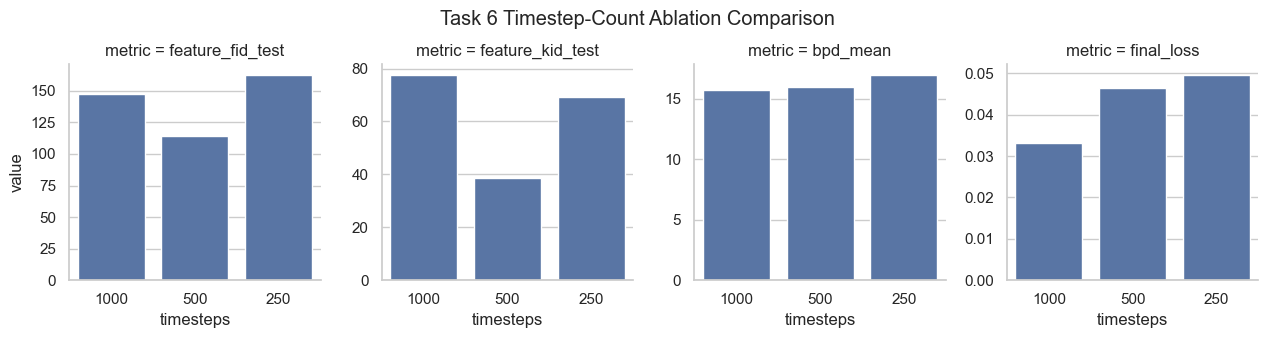

In [9]:
timestep_df = pd.DataFrame(timestep_ablation_results).sort_values(["timesteps", "run_seed"], ascending=[False, True])
per_run_cols = [
    c for c in [
        "name",
        "run_seed",
        "timesteps",
        "final_loss",
        "feature_fid_test",
        "feature_kid_test",
        "generated_class_entropy_normalized",
        "generated_mean_confidence",
        "bpd_mean",
    ]
    if c in timestep_df.columns
]
display(timestep_df[per_run_cols])

summary_metrics = [
    c for c in [
        "final_loss",
        "feature_fid_test",
        "feature_kid_test",
        "generated_class_entropy_normalized",
        "generated_mean_confidence",
        "bpd_mean",
    ]
    if c in timestep_df.columns
]
timestep_summary = timestep_df.groupby("timesteps")[summary_metrics].agg(["mean", "std"])
display(timestep_summary.round(4))

plot_df = timestep_df.copy()
plot_df["timesteps"] = plot_df["timesteps"].astype(int).astype(str)
timestep_plot_cols = [c for c in ["feature_fid_test", "feature_kid_test", "bpd_mean", "final_loss"] if c in plot_df.columns]
if len(timestep_plot_cols) > 0:
    fig, axes = plt.subplots(1, len(timestep_plot_cols), figsize=(4.2 * len(timestep_plot_cols), 3.8))
    if len(timestep_plot_cols) == 1:
        axes = [axes]
    for ax, metric in zip(axes, timestep_plot_cols):
        sns.barplot(data=plot_df, x="timesteps", y=metric, estimator="mean", errorbar="sd", ax=ax)
        ax.set_title(metric)
        ax.set_xlabel("timesteps")
        ax.set_ylabel(metric)
    fig.suptitle("Task 6 Timestep Ablation: mean +/- sd across seeds", y=1.05)
    fig.tight_layout()
    plt.show()

loss_rows = []
for _, row in timestep_df.iterrows():
    for step, loss in enumerate(row["loss_history"], start=1):
        loss_rows.append({
            "timesteps": int(row["timesteps"]),
            "run_seed": int(row["run_seed"]),
            "step": step,
            "loss": loss,
        })
loss_df = pd.DataFrame(loss_rows)

plt.figure(figsize=(10, 5))
for timesteps_value in sorted(loss_df["timesteps"].unique(), reverse=True):
    subset = loss_df[loss_df["timesteps"] == timesteps_value]
    for run_seed in sorted(subset["run_seed"].unique()):
        seed_subset = subset[subset["run_seed"] == run_seed]
        plt.plot(seed_subset["step"], seed_subset["loss"], alpha=0.22, linewidth=1.0, label=None)

mean_loss_df = loss_df.groupby(["timesteps", "step"], as_index=False)["loss"].mean()
sns.lineplot(data=mean_loss_df, x="step", y="loss", hue="timesteps", linewidth=2.5, palette="deep")
plt.title("Task 6 Timestep Ablation Training Loss")
plt.xlabel("Training step")
plt.ylabel("MSE loss")
plt.tight_layout()
plt.show()


## Toy data quick check

This is just a low-dimensional sanity check for the metric utilities, not part of the main MNIST story.

In [10]:
toy_real_np, _ = make_moons(n_samples=1000, noise=0.05, random_state=42)
toy_generated_np = toy_real_np + 0.08 * torch.randn(1000, 2).numpy()

toy_real = torch.tensor(toy_real_np, dtype=torch.float32)
toy_generated = torch.tensor(toy_generated_np, dtype=torch.float32)

toy_swd = sliced_wasserstein_distance_2d(toy_real, toy_generated, num_projections=64)
toy_mmd = rbf_mmd_2d(toy_real, toy_generated, sigma=0.2)
toy_plot_path = save_toy_scatter(toy_real, toy_generated)

print("toy_swd:", toy_swd)
print("toy_rbf_mmd:", toy_mmd)
print("toy_scatter:", toy_plot_path)


toy_swd: 0.014782314440947691
toy_rbf_mmd: 0.001137257905005462
toy_scatter: C:\Users\ahmad\Documents\GitHub\Learning Diffusion Models\dvlm-pa1-ddpm\outputs\figures\task6_toy_scatter.png
